<a href="https://colab.research.google.com/github/ARJUN108-verma/arjun/blob/main/Pandas_framework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Load a pandas DataFrame

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf

SHUFFLE_BUFFER = 500
BATCH_SIZE = 2

In [2]:
#download the csv file
csv_file = tf.keras.utils.get_file('heart.csv','https://storage.googleapis.com/download.tensorflow.org/data/heart.csv')

13273/13273 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
#read
df = pd.read_csv(csv_file)

In [4]:
#look of data
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,fixed,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,normal,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,reversible,0
3,37,1,3,130,250,0,0,187,0,3.5,3,0,normal,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,normal,0


In [5]:
#data types
df.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [6]:
target = df.pop('target')

In [7]:
#a data frame as an array
numeric_feature_names = ['age','thalach','trestbps','chol','oldpeak']
numeric_features = df[numeric_feature_names]
numeric_features.head()

,age,thalach,trestbps,chol,oldpeak
0,63,150,145,233,2.3
1,67,108,160,286,1.5
2,67,129,120,229,2.6
3,37,187,130,250,3.5
4,41,172,130,204,1.4


In [8]:
#convert the data
tf.convert_to_tensor(numeric_features)

<tf.Tensor: shape=(303, 5), dtype=float64, numpy=
array([[ 63. , 150. , 145. , 233. ,   2.3],
       [ 67. , 108. , 160. , 286. ,   1.5],
       [ 67. , 129. , 120. , 229. ,   2.6],
       ...,
       [ 65. , 127. , 135. , 254. ,   2.8],
       [ 48. , 150. , 130. , 256. ,   0. ],
       [ 63. , 154. , 150. , 407. ,   4. ]])>

In [9]:
#normalization
normalizer = tf.keras.layers.Normalization(axis=-1)
normalizer.adapt(np.array(numeric_features))

In [10]:
#call the first three rows of the data
normalizer(numeric_features.iloc[:3])

<tf.Tensor: shape=(3, 5), dtype=float32, numpy=
array([[ 0.93384   ,  0.03480783,  0.74578166, -0.26008663,  1.0680453 ],
       [ 1.3782114 , -1.7806157 ,  1.5923294 ,  0.75738776,  0.38022864],
       [ 1.3782114 , -0.87290394, -0.6651312 , -0.33687717,  1.3259765 ]],
      dtype=float32)>

In [11]:
#use normalize layer as the first layer of a simple model
def get_basic_model():
  model = tf.keras.Sequential([
      normalizer,
      tf.keras.layers.Dense(10, activation='relu'),
      tf.keras.layers.Dense(10, activation='relu'),
      tf.keras.layers.Dense(1)
  ])


  model.compile(optimizer = 'adam',
                loss = tf.keras.losses.BinaryCrossentropy(from_logits=True),
                metrics=['accuracy'])
  return model

In [12]:
model = get_basic_model()
model.fit(numeric_features, target, epochs = 15, batch_size=BATCH_SIZE)

Epoch 1/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7393 - loss: 0.6452
Epoch 2/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6950 - loss: 0.5894
Epoch 3/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7164 - loss: 0.5456
Epoch 4/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7143 - loss: 0.5121
Epoch 5/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7429 - loss: 0.4678
Epoch 6/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7482 - loss: 0.4724
Epoch 7/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7285 - loss: 0.4533
Epoch 8/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7097 - loss: 0.4973
Epoch 9/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7952 - loss: 0.4119
Epoch 10/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7525 - loss: 0.4391
Epoch 11/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7756 - loss: 0.4248
Epoch 12/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

In [13]:
numeric_dataset = tf.data.Dataset.from_tensor_slices((numeric_features, target))

for row in numeric_dataset.take(3):
  print(row)

(<tf.Tensor: shape=(5,), dtype=float64, numpy=array([ 63. , 150. , 145. , 233. ,   2.3])>, <tf.Tensor: shape=(), dtype=int64, numpy=0>)
(<tf.Tensor: shape=(5,), dtype=float64, numpy=array([ 67. , 108. , 160. , 286. ,   1.5])>, <tf.Tensor: shape=(), dtype=int64, numpy=1>)
(<tf.Tensor: shape=(5,), dtype=float64, numpy=array([ 67. , 129. , 120. , 229. ,   2.6])>, <tf.Tensor: shape=(), dtype=int64, numpy=0>)


In [14]:
numeric_batches = numeric_dataset.shuffle(1000).batch(BATCH_SIZE)

model = get_basic_model()
model.fit(numeric_batches, epochs = 15)


Epoch 1/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7064 - loss: 0.6264
Epoch 2/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7088 - loss: 0.5347
Epoch 3/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7069 - loss: 0.5384
Epoch 4/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7499 - loss: 0.4618
Epoch 5/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7516 - loss: 0.4571
Epoch 6/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8234 - loss: 0.3566
Epoch 7/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8023 - loss: 0.4308
Epoch 8/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8447 - loss: 0.3666
Epoch 9/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7941 - loss: 0.4376
Epoch 10/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7998 - loss: 0.4075
Epoch 11/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7929 - loss: 0.4008
Epoch 12/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

In [15]:
numeric_features_dict = {key: value.to_numpy()[:, tf.newaxis] for key, value in dict(numeric_features).items()}
target_array = target.to_numpy()[:, tf.newaxis]

In [16]:
numeric_dict_ds = tf.data.Dataset.from_tensor_slices((numeric_features_dict, target_array))

In [17]:
len(numeric_features_dict)

5

In [18]:
#example
for row in numeric_dict_ds.take(3):
  print(row)

({'age': <tf.Tensor: shape=(1,), dtype=int64, numpy=array([63])>, 'thalach': <tf.Tensor: shape=(1,), dtype=int64, numpy=array([150])>, 'trestbps': <tf.Tensor: shape=(1,), dtype=int64, numpy=array([145])>, 'chol': <tf.Tensor: shape=(1,), dtype=int64, numpy=array([233])>, 'oldpeak': <tf.Tensor: shape=(1,), dtype=float64, numpy=array([2.3])>}, <tf.Tensor: shape=(1,), dtype=int64, numpy=array([0])>)
({'age': <tf.Tensor: shape=(1,), dtype=int64, numpy=array([67])>, 'thalach': <tf.Tensor: shape=(1,), dtype=int64, numpy=array([108])>, 'trestbps': <tf.Tensor: shape=(1,), dtype=int64, numpy=array([160])>, 'chol': <tf.Tensor: shape=(1,), dtype=int64, numpy=array([286])>, 'oldpeak': <tf.Tensor: shape=(1,), dtype=float64, numpy=array([1.5])>}, <tf.Tensor: shape=(1,), dtype=int64, numpy=array([1])>)
({'age': <tf.Tensor: shape=(1,), dtype=int64, numpy=array([67])>, 'thalach': <tf.Tensor: shape=(1,), dtype=int64, numpy=array([129])>, 'trestbps': <tf.Tensor: shape=(1,), dtype=int64, numpy=array([120])

The Model-subclass style

In [22]:
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Concatenate, Dense

# Define separate inputs
inputs = {
    name: Input(shape=(1,), name=name)
    for name in ['age', 'thalach', 'trestbps', 'chol', 'oldpeak']
}

# Concatenate the inputs
concat = Concatenate()(list(inputs.values()))

# Add dense layers
x = Dense(32, activation='relu')(concat)
x = Dense(16, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

# Build model
model = Model(inputs=inputs, outputs=output)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [23]:
model.fit(numeric_features_dict, target_array, epochs=5, batch_size=BATCH_SIZE)


Epoch 1/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6691 - loss: 1.0300
Epoch 2/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7286 - loss: 0.5696
Epoch 3/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7015 - loss: 0.5955
Epoch 4/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6931 - loss: 0.6898
Epoch 5/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7114 - loss: 0.6132


In [25]:
numeric_dict_batches = numeric_dict_ds.shuffle(SHUFFLE_BUFFER).batch(BATCH_SIZE)
model.fit(numeric_dict_batches, epochs=5)

Epoch 1/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7413 - loss: 0.5026
Epoch 2/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7183 - loss: 0.5961
Epoch 3/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7155 - loss: 0.5461
Epoch 4/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7486 - loss: 0.5325
Epoch 5/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7158 - loss: 0.5206


In [26]:
#prediction
model.predict(dict(numeric_features.iloc[:3]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


array([[0.13733135],
       [0.59248716],
       [0.24542534]], dtype=float32)

The Keras function style

In [27]:
inputs = {}
for name, column in numeric_features.items():
  inputs[name] = tf.keras.Input(
      shape=(1,), name=name, dtype=tf.float32
  )
  inputs

In [28]:
xs = [value for key, value in sorted(inputs.items())]

concat = tf.keras.layers.Concatenate(axis=1)
x = concat(xs)

normalizer = tf.keras.layers.Normalization(axis=-1)
normalizer.adapt(np.concatenate([value for key, value in sorted(numeric_features_dict.items())], axis=1))

x = normalizer(x)
x = tf.keras.layers.Dense(10, activation='relu')(x)
x = tf.keras.layers.Dense(10, activation='relu')(x)
x = tf.keras.layers.Dense(1)(x)

model = tf.keras.Model(inputs, x)

model.compile(optimizer='adam',
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              metrics=['accuracy'],
              run_eagerly=True)

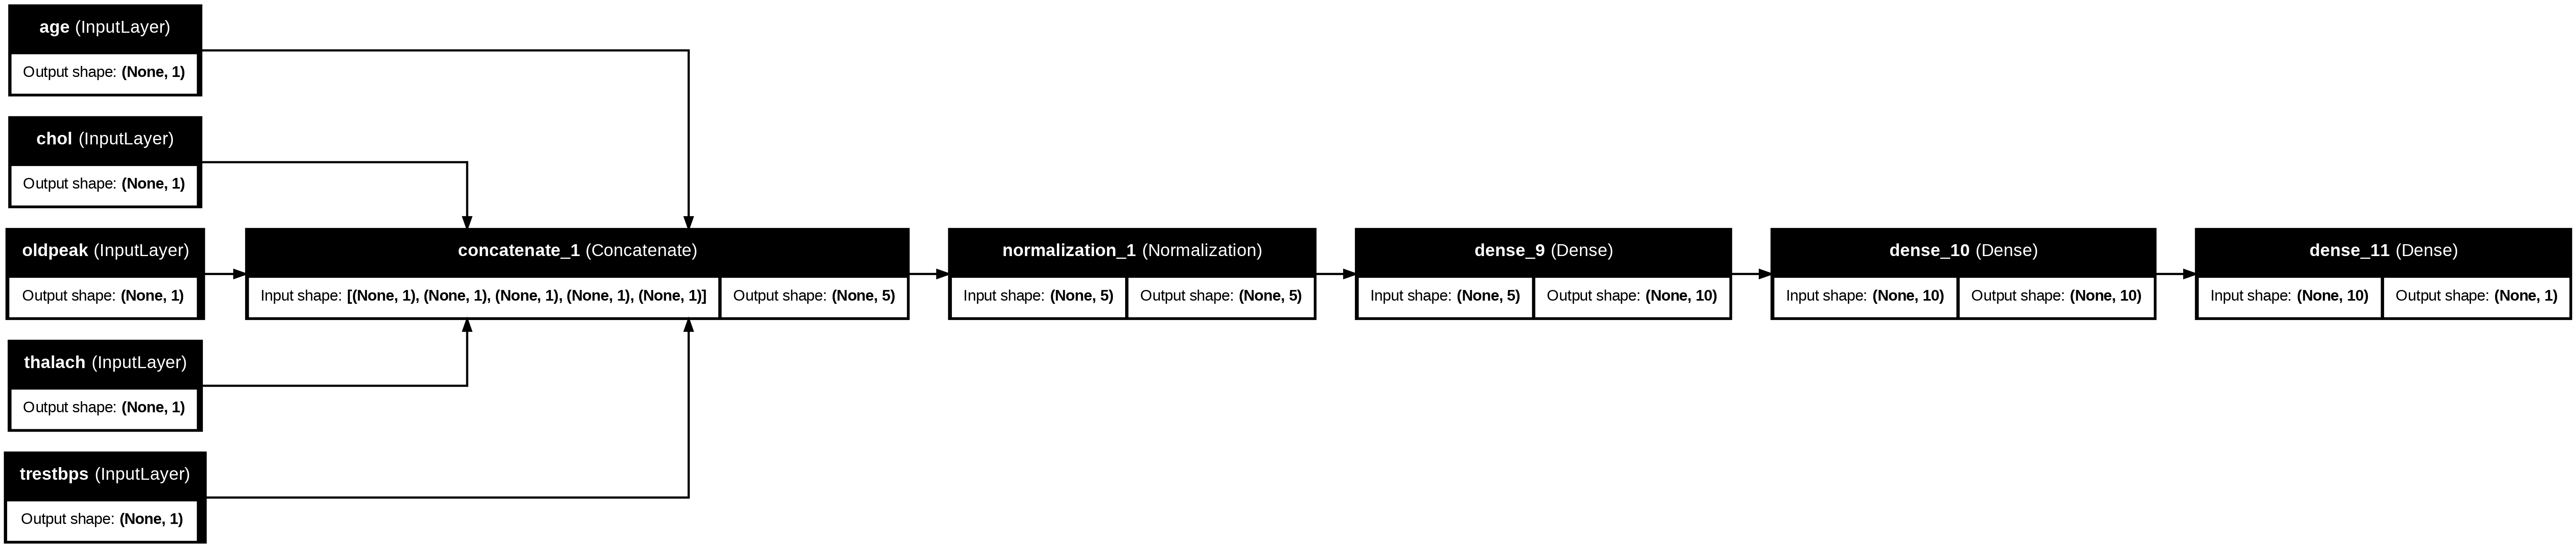

In [29]:
tf.keras.utils.plot_model(model, rankdir="LR", show_shapes=True,  show_layer_names=True)

In [30]:
model.fit(numeric_features_dict, target, epochs=5, batch_size=BATCH_SIZE)

Epoch 1/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.7086 - loss: 0.6826
Epoch 2/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.7707 - loss: 0.5025
Epoch 3/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step - accuracy: 0.7105 - loss: 0.4969
Epoch 4/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - accuracy: 0.7392 - loss: 0.4717
Epoch 5/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 11s 58ms/step - accuracy: 0.6942 - loss: 0.5242


In [31]:
numeric_dict_batches = numeric_dict_ds.shuffle(SHUFFLE_BUFFER).batch(BATCH_SIZE)
model.fit(numeric_dict_batches, epochs=5)

Epoch 1/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.7948 - loss: 0.4155
Epoch 2/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 11s 67ms/step - accuracy: 0.7656 - loss: 0.4202
Epoch 3/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.7798 - loss: 0.4632
Epoch 4/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.7636 - loss: 0.4409
Epoch 5/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.7781 - loss: 0.4081


Full example

Build the preprocessing head

In [32]:
binary_feature_names = ['sex', 'fbs', 'exang']

In [33]:
categorical_feature_names = ['cp', 'restecg', 'slope', 'thal', 'ca']

In [34]:
inputs = {}
for name, column in df.items():
  if type(column[0]) == str:
    dtype = tf.string
  elif (name in categorical_feature_names or
        name in binary_feature_names):
    dtype = tf.int64
  else:
    dtype = tf.float32

  inputs[name] = tf.keras.Input(shape=(1,), name=name, dtype=dtype)

In [35]:
inputs

{'age': <KerasTensor shape=(None, 1), dtype=float32, sparse=False, name=age>,
 'sex': <KerasTensor shape=(None, 1), dtype=int64, sparse=False, name=sex>,
 'cp': <KerasTensor shape=(None, 1), dtype=int64, sparse=False, name=cp>,
 'trestbps': <KerasTensor shape=(None, 1), dtype=float32, sparse=False, name=trestbps>,
 'chol': <KerasTensor shape=(None, 1), dtype=float32, sparse=False, name=chol>,
 'fbs': <KerasTensor shape=(None, 1), dtype=int64, sparse=False, name=fbs>,
 'restecg': <KerasTensor shape=(None, 1), dtype=int64, sparse=False, name=restecg>,
 'thalach': <KerasTensor shape=(None, 1), dtype=float32, sparse=False, name=thalach>,
 'exang': <KerasTensor shape=(None, 1), dtype=int64, sparse=False, name=exang>,
 'oldpeak': <KerasTensor shape=(None, 1), dtype=float32, sparse=False, name=oldpeak>,
 'slope': <KerasTensor shape=(None, 1), dtype=int64, sparse=False, name=slope>,
 'ca': <KerasTensor shape=(None, 1), dtype=int64, sparse=False, name=ca>,
 'thal': <KerasTensor shape=(None, 1),

In [36]:
preprocessed = []

for name in binary_feature_names:
  inp = inputs[name]
  preprocessed.append(inp)

preprocessed

[<KerasTensor shape=(None, 1), dtype=int64, sparse=False, name=sex>,
 <KerasTensor shape=(None, 1), dtype=int64, sparse=False, name=fbs>,
 <KerasTensor shape=(None, 1), dtype=int64, sparse=False, name=exang>]

In [37]:
normalizer = tf.keras.layers.Normalization(axis=-1)
normalizer.adapt(np.concatenate([value for key, value in sorted(numeric_features_dict.items())], axis=1))

In [38]:
numeric_inputs = []
for name in numeric_feature_names:
  numeric_inputs.append(inputs[name])

numeric_inputs = tf.keras.layers.Concatenate(axis=-1)(numeric_inputs)
numeric_normalized = normalizer(numeric_inputs)

preprocessed.append(numeric_normalized)

preprocessed

[<KerasTensor shape=(None, 1), dtype=int64, sparse=False, name=sex>,
 <KerasTensor shape=(None, 1), dtype=int64, sparse=False, name=fbs>,
 <KerasTensor shape=(None, 1), dtype=int64, sparse=False, name=exang>,
 <KerasTensor shape=(None, 5), dtype=float32, sparse=False, name=keras_tensor_20>]

In [39]:
vocab = ['a','b','c']
lookup = tf.keras.layers.StringLookup(vocabulary=vocab, output_mode='one_hot')
lookup(['c','a','a','b','zzz'])

<tf.Tensor: shape=(5, 4), dtype=int64, numpy=
array([[0, 0, 0, 1],
       [0, 1, 0, 0],
       [0, 1, 0, 0],
       [0, 0, 1, 0],
       [1, 0, 0, 0]])>

In [40]:
vocab = [1,4,7,99]
lookup = tf.keras.layers.IntegerLookup(vocabulary=vocab, output_mode='one_hot')

lookup([-1,4,1])

<tf.Tensor: shape=(3, 5), dtype=int64, numpy=
array([[1, 0, 0, 0, 0],
       [0, 0, 1, 0, 0],
       [0, 1, 0, 0, 0]])>

In [41]:
for name in categorical_feature_names:
  vocab = sorted(set(df[name]))
  print(f'name: {name}')
  print(f'vocab: {vocab}\n')

  if type(vocab[0]) is str:
    lookup = tf.keras.layers.StringLookup(vocabulary=vocab, output_mode='one_hot')
  else:
    lookup = tf.keras.layers.IntegerLookup(vocabulary=vocab, output_mode='one_hot')

  x = inputs[name]
  x = lookup(x)
  preprocessed.append(x)

name: cp
vocab: [0, 1, 2, 3, 4]

name: restecg
vocab: [0, 1, 2]

name: slope
vocab: [1, 2, 3]

name: thal
vocab: ['1', '2', 'fixed', 'normal', 'reversible']

name: ca
vocab: [0, 1, 2, 3]



In [42]:
preprocessed

[<KerasTensor shape=(None, 1), dtype=int64, sparse=False, name=sex>,
 <KerasTensor shape=(None, 1), dtype=int64, sparse=False, name=fbs>,
 <KerasTensor shape=(None, 1), dtype=int64, sparse=False, name=exang>,
 <KerasTensor shape=(None, 5), dtype=float32, sparse=False, name=keras_tensor_20>,
 <KerasTensor shape=(None, 6), dtype=float32, sparse=False, name=keras_tensor_21>,
 <KerasTensor shape=(None, 4), dtype=float32, sparse=False, name=keras_tensor_22>,
 <KerasTensor shape=(None, 4), dtype=float32, sparse=False, name=keras_tensor_23>,
 <KerasTensor shape=(None, 6), dtype=float32, sparse=False, name=keras_tensor_24>,
 <KerasTensor shape=(None, 5), dtype=float32, sparse=False, name=keras_tensor_25>]

In [43]:
preprocessed_result = tf.keras.layers.Concatenate(axis=1)(preprocessed)
preprocessed_result

<KerasTensor shape=(None, 33), dtype=float32, sparse=False, name=keras_tensor_26>

In [44]:
preprocessor = tf.keras.Model(inputs, preprocessed_result)

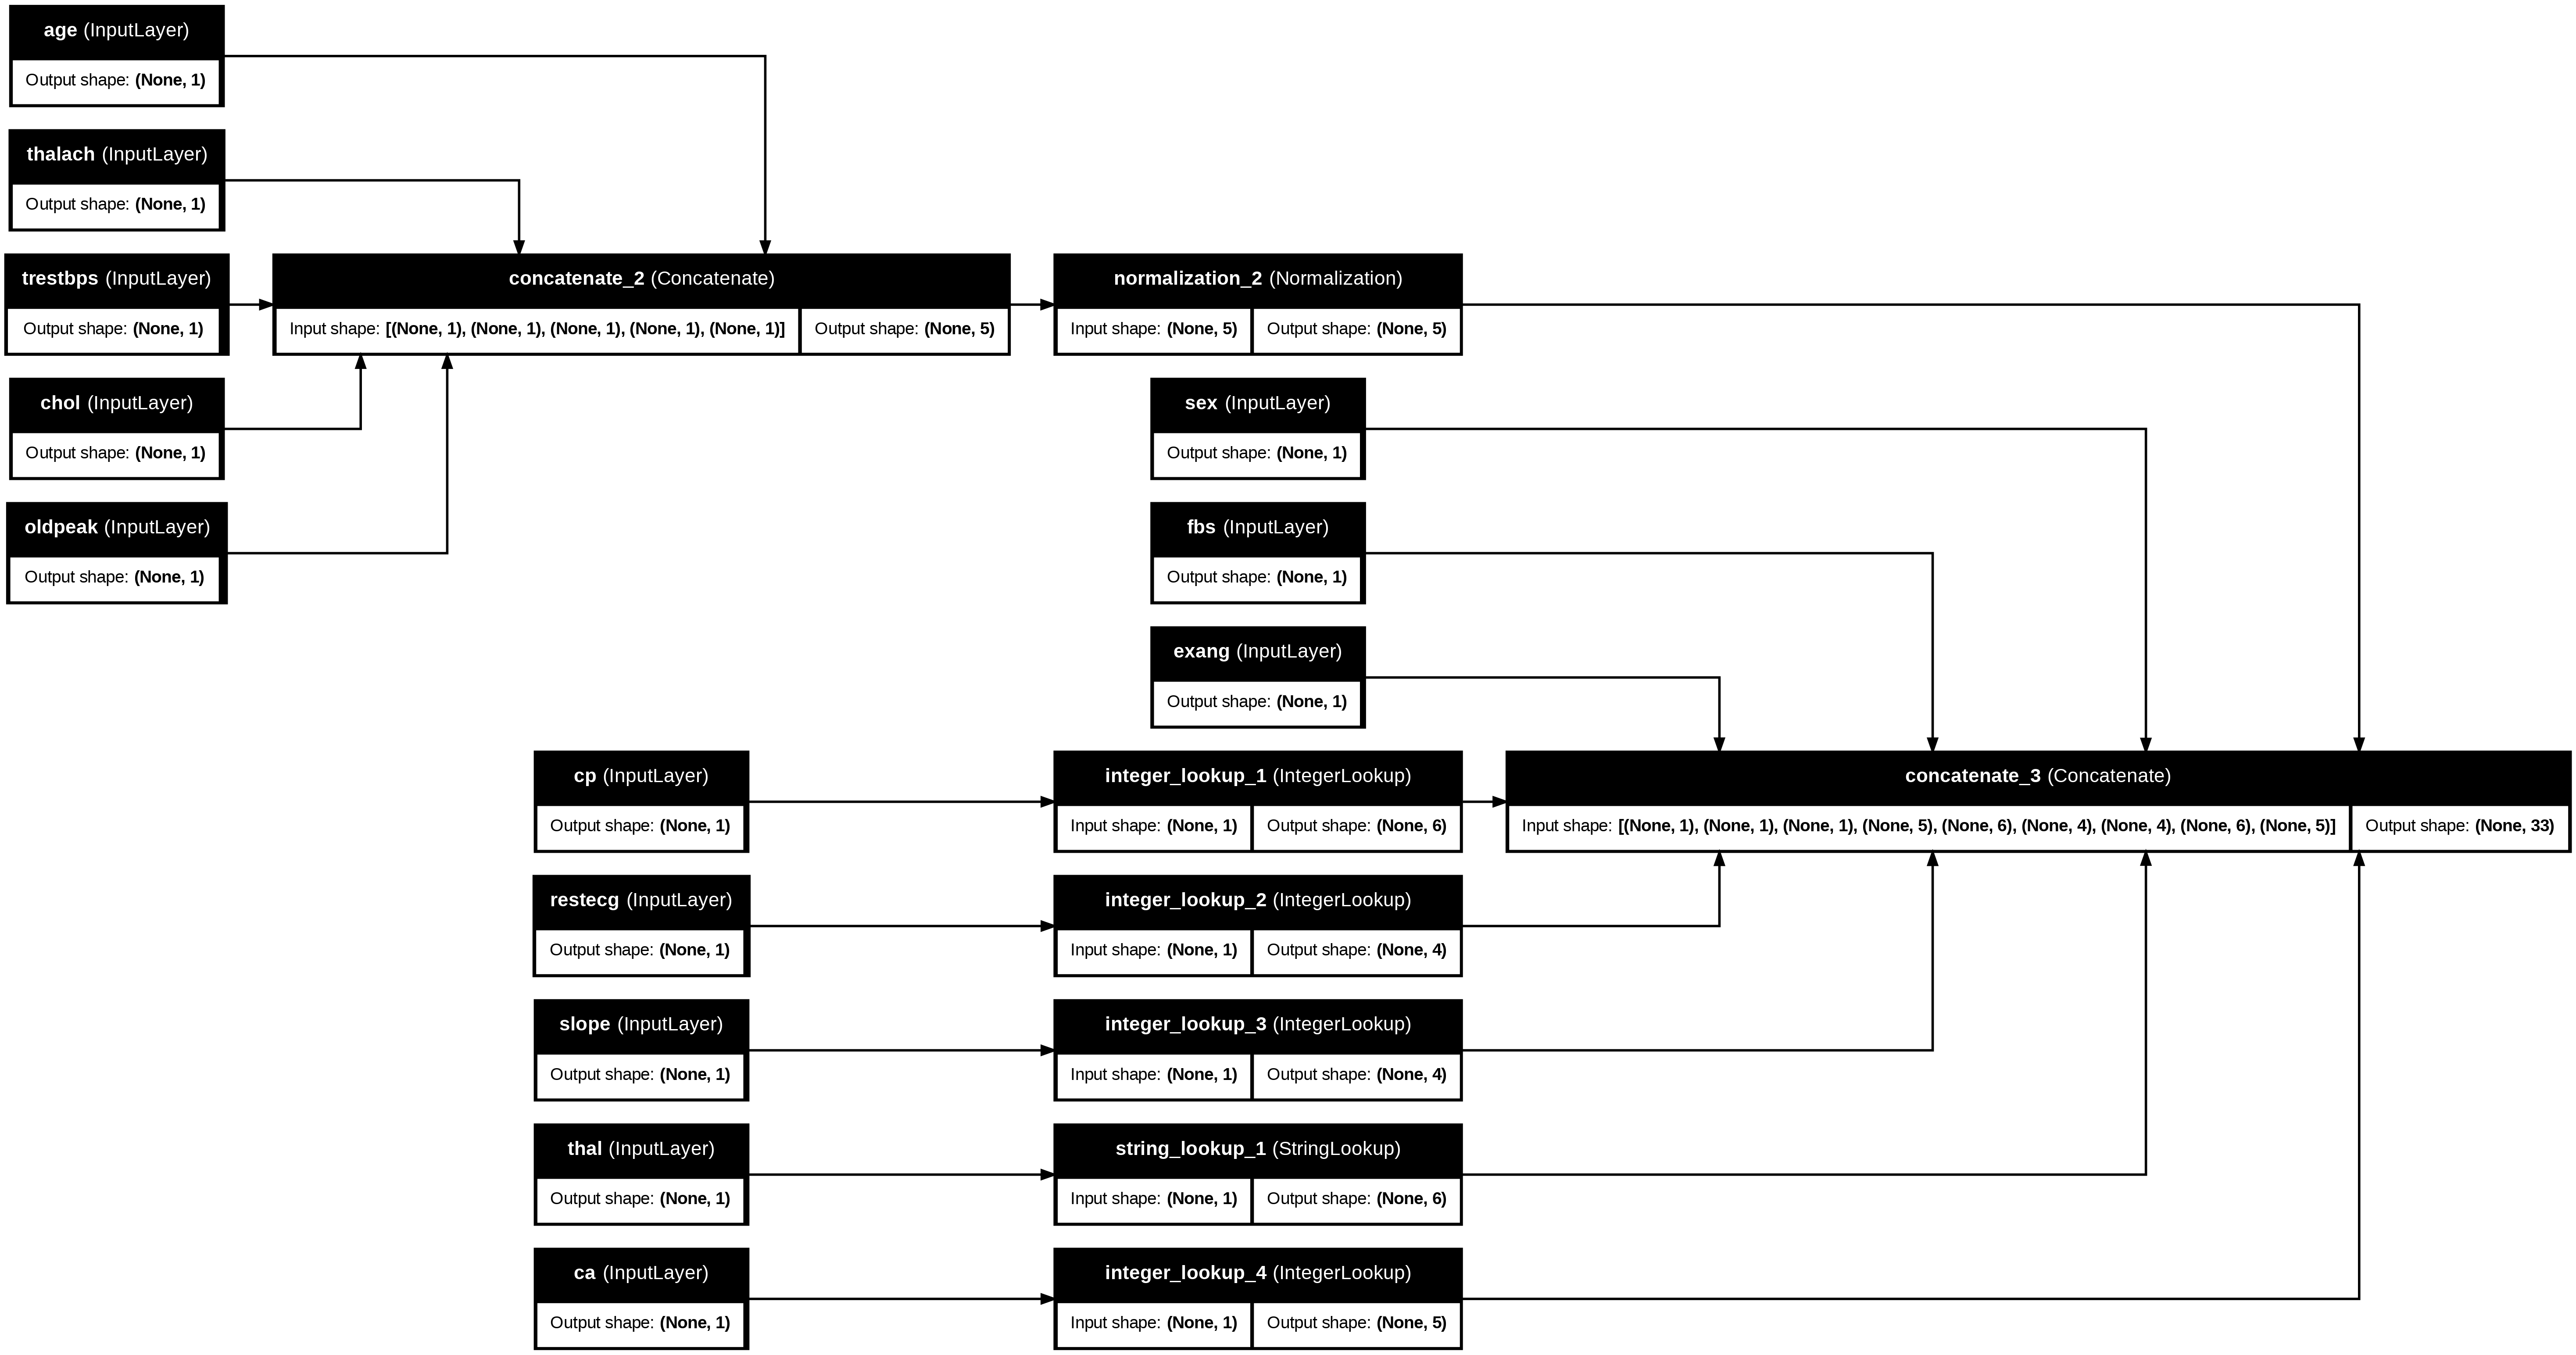

In [45]:
tf.keras.utils.plot_model(preprocessor, rankdir="LR", show_shapes=True,  show_layer_names=True)

In [46]:
preprocessor(dict(df.iloc[:1]))

<tf.Tensor: shape=(1, 33), dtype=float32, numpy=
array([[  1.       ,   1.       ,   0.       ,   0.93384  ,  -1.8534899,
        123.75735  ,   3.6224306,  -7.3077087,   0.       ,   0.       ,
          1.       ,   0.       ,   0.       ,   0.       ,   0.       ,
          0.       ,   0.       ,   1.       ,   0.       ,   0.       ,
          0.       ,   1.       ,   0.       ,   0.       ,   0.       ,
          1.       ,   0.       ,   0.       ,   0.       ,   1.       ,
          0.       ,   0.       ,   0.       ]], dtype=float32)>